In [1]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW, lr_scheduler
from transformers import get_cosine_schedule_with_warmup, DistilBertModel, DistilBertTokenizer, DistilBertConfig

from sklearn.model_selection import  train_test_split
import gc
import re
from time import time

In [2]:
seed = 19971204
torch.manual_seed(seed)
np.random.seed(seed)
# for cuda
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

In [3]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

cuda:0


In [4]:
trainDataset = pd.read_csv('../dataset/text/train_json.csv')

# valDataset = pd.read_csv('../dataset/text/harish_dataset/dev_json.csv')

# testDataset = pd.read_csv('../dataset/text/harish_dataset/test_json.csv')

In [5]:
trainDataset = trainDataset.drop(trainDataset[(trainDataset['finegrained'] == 'Proper Noun') | (trainDataset['finegrained'] ==  'Meta Usage')].index)
# trainDataset = trainDataset.drop(trainDataset.loc[trainDataset['mwe'] == 'academy award'].index)

In [6]:
trainDataset.shape

(3110, 16)

In [7]:
model_class, tokenizer_class, pretrained_weights, config_class = (DistilBertModel, DistilBertTokenizer, 'distilbert-base-uncased', DistilBertConfig)

tokenizer = tokenizer_class.from_pretrained(pretrained_weights)

In [8]:
def preprocess_text(sen):

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sen)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    sentence = sentence.lower()

    return sentence

In [9]:
def bertTokens(textDataset):

    at_sentences = textDataset['at']
    mwes = textDataset['mwe']

    sentences = ['.'.join([mwe, preprocess_text(sent)]) for mwe, sent in list(zip(mwes, at_sentences))]
    
    tokenized = [tokenizer.encode(mwe, sent, add_special_tokens=True) for mwe, sent in list(zip(mwes, at_sentences))]
    # sentences.apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

    max_len = 0 
    for i in tokenized:
        if len(i) > max_len:
            max_len = len(i)

    input_ids = np.array([i + [0]*(max_len-len(i)) for i in tokenized])

    attention_mask = np.where(input_ids != 0, 1, 0)

    labels=textDataset['0I/1L'].tolist()

    return input_ids, attention_mask, labels

In [10]:
train_tokens = bertTokens(trainDataset)
# dev_tokens = bertTokens(valDataset)
# test_tokens = bertTokens(testDataset)

In [78]:
from collections import Counter

count = Counter(train_tokens[2])
count

Counter({1: 1274, 0: 1836})

In [11]:
bert_train_df = pd.DataFrame(list(zip(train_tokens[0], train_tokens[1], train_tokens[2])), columns=['input_ids', 'attention_mask', 'labels'])

# bert_dev_df = pd.DataFrame(list(zip(dev_tokens[0], dev_tokens[1], dev_tokens[2])), columns=['input_ids', 'attention_mask', 'labels'])

# bert_test_df = pd.DataFrame(list(zip(test_tokens[0], test_tokens[1], test_tokens[2])), columns=['input_ids', 'attention_mask', 'labels'])

In [12]:
labels = bert_train_df['labels']
bert_train_df = bert_train_df.drop(columns=['labels'], axis=1)
# bert_train_df.head()

In [13]:
temp_text, test_text, temp_labels, test_labels = train_test_split(bert_train_df, labels,
                              test_size=0.1, stratify=labels)

train_text, val_text, train_labels, val_labels = train_test_split(temp_text, temp_labels,
                          test_size=0.1, stratify=temp_labels)

In [82]:
Counter(test_labels)

Counter({0: 184, 1: 127})

In [14]:
del temp_text
gc.collect()
torch.cuda.empty_cache()

# train_count = len(train_labels)
# test_count = len(test_labels)
# val_count = len(val_labels)
# (train_count, test_count, val_count)

In [15]:
# for train set
train_seq = torch.tensor(train_text['input_ids'].tolist())
train_mask = torch.tensor(train_text['attention_mask'].tolist())
train_y = torch.tensor(train_labels.to_list())

# for validation set
val_seq = torch.tensor(val_text['input_ids'].tolist())
val_mask = torch.tensor(val_text['attention_mask'].tolist())
val_y = torch.tensor(val_labels.to_list())

# for test set
test_seq = torch.tensor(test_text['input_ids'].tolist())
test_mask = torch.tensor(test_text['attention_mask'].tolist())
test_y = torch.tensor(test_labels.to_list())


# # for validation set
# val_seq = torch.tensor(bert_dev_df['input_ids'].tolist())
# val_mask = torch.tensor(bert_dev_df['attention_mask'].tolist())
# val_y = torch.tensor(bert_dev_df['labels'])


# # for test set
# test_seq = torch.tensor(bert_test_df['input_ids'].tolist())
# test_mask = torch.tensor(bert_test_df['attention_mask'].tolist())
# test_y = torch.tensor(bert_test_df['labels'])

In [14]:
BATCH_SIZE=16

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=BATCH_SIZE)


# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=BATCH_SIZE)

In [19]:
class Net(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        # config = BertConfig.from_pretrained(pretrained_weights, output_attentions=True)
        # self.bert = model_class.from_pretrained(pretrained_weights, config=config)   

        self.layer_dim = hidden_size     
        
        self.regr1 = nn.Linear(self.layer_dim, self.layer_dim)
        self.relu = nn.LeakyReLU(negative_slope=0.01)
        self.regr2 = nn.Linear(self.layer_dim, 2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, outputs):
        #Feed the input to Bert model to obtain contextualized representations
        # outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        #Obtain the representations of [CLS] heads
        logits = outputs.last_hidden_state[:,0,:]
        output = self.relu(self.regr1(logits))
        output = self.relu(self.regr2(output))
        return self.softmax(output)

In [ ]:
config = config_class.from_pretrained(pretrained_weights, output_attentions=True)
bertModel = model_class.from_pretrained(pretrained_weights, config=config)  
bertModel = bertModel.to(device)

In [21]:
bertLayers = Net(config.hidden_size)
bertLayers = bertLayers.to(device)

In [18]:
LR = 1e-5
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()
criterion.to(device)
optimizer = AdamW(bertLayers.parameters(), lr=LR)

In [19]:
# from transformers import get_linear_schedule_with_warmup

num_training_steps = NUM_EPOCHS+2
num_warmup_steps = 2

# scheduler = get_cosine_schedule_with_warmup(
#     optimizer, num_warmup_steps=num_warmup_steps, 
#     num_training_steps=num_training_steps)

scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min')

# total_steps = len(train_dataloader) * NUM_EPOCHS

# scheduler = get_linear_schedule_with_warmup(
#     optimizer, num_warmup_steps=0, 
#     num_training_steps=total_steps)

# iters = len(train_dataloader)
# step_size = iters * 2

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=5, gamma=0.1)

In [24]:
def training():
    print('Training')
    bertLayers.train()
    total_loss, total_accuracy = 0, 0
    
    # total_preds = []
    running_corrects=0
    # iterate over batches
    total = len(train_dataloader)

    print(f'With lr: {optimizer.param_groups[0]["lr"]:.8f}')
    for i, batch in enumerate(train_dataloader):
        # push the batch to gpu
        batch = [r.to(device) for r in batch]
        sent_id, mask, labels = batch
        del batch
        gc.collect()
        torch.cuda.empty_cache()
        # clear previously calculated gradients
        optimizer.zero_grad()
        
        # get model predictions for the current batch
        
        inputs = bertModel(sent_id, attention_mask=mask)
            
        outputs = bertLayers(inputs)
        # compute the loss between actual and predicted values
        loss = criterion(outputs, labels)
        # add on to the total loss
        total_loss += float(loss.item())

        _, preds = torch.max(outputs, 1)
        # preds = np.concatenate(outputs, axis=0)

        # backward pass to calculate the gradients
        loss.backward()
        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(bertLayers.parameters(), 1.0)
        # update parameters
        optimizer.step()
        
        # total_preds.append(outputs.detach().cpu().numpy())
        preds = preds.view(labels.size()).data
        running_corrects += torch.sum(preds == labels.data)

    gc.collect()
    torch.cuda.empty_cache()

    # compute the training loss of the epoch
    avg_loss = total_loss / (total*BATCH_SIZE)
    total_accuracy = running_corrects / (total*BATCH_SIZE)

    
    # total_preds = np.concatenate(total_preds, axis=0)

    # returns the loss and predictions
    return avg_loss, total_accuracy

In [25]:
def evaluate():
    print("Evaluating...")

    # deactivate dropout layers
    bertLayers.eval()

    total_loss, total_accuracy = 0, 0
    running_corrects = 0

    # empty list to save the model predictions
    # total_preds = []

    # iterate over batches
    total = len(val_dataloader)
    for i, batch in enumerate(val_dataloader):

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch
        del batch
        gc.collect()
        torch.cuda.empty_cache()
        # deactivate autograd
        with torch.no_grad():

            # model predictions
            inputs = bertModel(sent_id, attention_mask=mask)
            outputs = bertLayers(inputs)

            # compute the validation loss between actual and predicted values
            loss = criterion(outputs, labels)

            total_loss += float(loss.item())
            #preds = preds.detach().cpu().numpy()

            _, preds = torch.max(outputs, 1)
            # preds = np.concatenate(outputs, axis=0)

            #total_preds.append(preds)
            # total_preds.append(outputs.detach().cpu().numpy())
            preds = preds.view(labels.size()).data
            running_corrects += torch.sum(preds == labels.data)

    gc.collect()
    torch.cuda.empty_cache()

    # compute the validation loss of the epoch
    avg_loss = total_loss / (total*BATCH_SIZE)
    total_accuracy = running_corrects / (total*BATCH_SIZE)

    # reshape the predictions in form of (number of samples, no. of classes)
    # total_preds = np.concatenate(total_preds, axis=0)

    return avg_loss, total_accuracy

In [26]:
best_valid_loss = float('inf')
# MODEL=bertModel
train_losses=[]
valid_losses=[]
train_accuracies=[]
valid_accuracies=[]

In [27]:
since = time()
best_acc = 0
for epoch in range(NUM_EPOCHS):
        
    print('Epoch ', epoch+1)

    # train model
    train_loss, train_acc = training()
    # evaluate model
    valid_loss, valid_acc = evaluate()

    scheduler.step(valid_loss)

    # save the best model
    if valid_loss >= best_valid_loss:
        best_valid_loss = valid_loss
        best_acc = valid_acc   
        torch.save(bertLayers.state_dict(), 'weights/20210921_final_bert_trial_saved_weights.pth')
        print('Early stopping as {} > {}'.format(valid_loss, best_valid_loss))
        break
    else:
        best_valid_loss = valid_loss

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print('Training Loss: {:.4f} Acc: {:.4f}'.format(train_loss, train_acc))
    print('Validation Loss: {:.4f} Acc: {:.4f}'.format(valid_loss, valid_acc))
    print('\n\n')

time_elapsed = time() - since
print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
print('Best val Acc: {:4f}'.format(best_acc))
print('Best val loss: {:4f}'.format(best_valid_loss))

Epoch  1
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0426 Acc: 0.5020
Validation Loss: 0.0422 Acc: 0.5417



Epoch  2
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0418 Acc: 0.6243
Validation Loss: 0.0407 Acc: 0.7351



Epoch  3
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0405 Acc: 0.6938
Validation Loss: 0.0396 Acc: 0.7351



Epoch  4
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0397 Acc: 0.7021
Validation Loss: 0.0388 Acc: 0.7589



Epoch  5
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0392 Acc: 0.7064
Validation Loss: 0.0382 Acc: 0.7589



Epoch  6
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0386 Acc: 0.7164
Validation Loss: 0.0377 Acc: 0.7351



Epoch  7
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0381 Acc: 0.7138
Validation Loss: 0.0373 Acc: 0.7440



Epoch  8
Training
With lr: 0.00001000
Evaluating...
Training Loss: 0.0377 Acc: 0.7191
Validation Loss: 0.0369 Acc: 0.7470





In [28]:
print('Best val Acc: {:4f}'.format(valid_acc))

Best val Acc: 0.738095


In [29]:
torch.save(bertLayers.state_dict(), 'weights/20210922_final_bert_trial_saved_weights.pth')

In [49]:
# del bertModel
# del criterion
# gc.collect()
# torch.cuda.empty_cache()

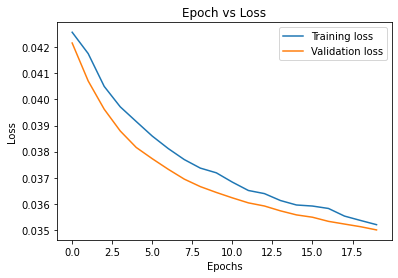

In [30]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()

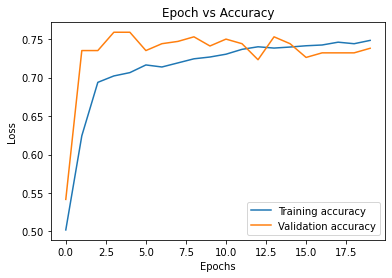

In [31]:
plt.plot(train_accuracies, label='Training accuracy')
plt.plot(valid_accuracies, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Accuracy')
plt.legend()
plt.show()

In [17]:
# dataLoader for test set
# wrap tensors

BATCH_SIZE=16

test_data = TensorDataset(test_seq, test_mask, test_y)

test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [22]:
best_model_wts = torch.load('weights/20210922_final_bert_trial_saved_weights.pth')

bertLayers.load_state_dict(best_model_wts)

<All keys matched successfully>

In [24]:
gc.collect()
torch.cuda.empty_cache()

In [23]:
predicted=[]
actuals=[]


with torch.no_grad():
        for i, batch in enumerate(test_dataloader):

            # push the batch to gpu
            batch = [t.to(device) for t in batch]

            sent_id, mask, labels = batch

            del batch
            gc.collect()
            torch.cuda.empty_cache()

            inputs = bertModel(sent_id, attention_mask=mask)
            outputs = bertLayers(inputs)
            # _, preds = torch.max(outputs, 1)

            preds = outputs.detach().cpu().numpy()
            predicted.extend(preds)
            actuals.extend(labels.detach().cpu().numpy())

In [24]:
#loaded model

from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

print("Performance:")
# model's performance
preds = np.argmax(predicted, axis=1)
print('Classification Report')
print(classification_report(actuals, preds))

print("Accuracy: " + str(accuracy_score(actuals, preds)))
print("Precision: " + str(precision_score(actuals, preds)))
print("Recall: " + str(recall_score(actuals, preds)))
print("F1 score: " + str(f1_score(actuals, preds, average='macro')))

Performance:
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       184
           1       0.74      0.75      0.75       127

    accuracy                           0.79       311
   macro avg       0.78      0.78      0.78       311
weighted avg       0.79      0.79      0.79       311

Accuracy: 0.7909967845659164
Precision: 0.7421875
Recall: 0.7480314960629921
F1 score: 0.7839931612972164


In [ ]:
percentages, _ = torch.max(torch.tensor(predicted), 1)

percent = [round(pc.item() * 100, 2) for pc in percentages]

In [29]:
pred_sent = []

for i in range(0, 10):

    sent = test_data[i][0].numpy()
    sent = tokenizer.decode(sent, skip_special_tokens=True)
    pred_sent.append(sent)
    print(sent)
    act_cla = 'Idiomatic' if not actuals[i] else 'Literal'
    print('Actual: ', act_cla)
    pre_cla = 'Idiomatic' if not preds[i] else 'Literal'
    print('Predicted: ', percent[i], '% ', pre_cla)

    print('-' * 10)

graveyard shift commonly referred to as the graveyard shift, this midnight to 7 or 8 a. m. shift is sometimes hard to staff.
Actual:  Idiomatic
Predicted:  64.2 %  Literal
----------
basket case venezuela provides limited aid, but that economy is now a wrecked basket case.
Actual:  Idiomatic
Predicted:  73.03 %  Idiomatic
----------
brain drain the remunerations of resident doctors need to be upgraded in order to discourage brain drain, while overseas training should also be encouraged.
Actual:  Idiomatic
Predicted:  60.96 %  Idiomatic
----------
role model he was a good role model who worked hard to break the chain of hatred and bigotry.
Actual:  Idiomatic
Predicted:  89.83 %  Idiomatic
----------
law firm in december, a coalition of creditors moved to force tom girardi and his law firm into involuntary bankruptcy, but the attorney never filed a response by the tuesday deadline.
Actual:  Literal
Predicted:  83.45 %  Literal
----------
cheat sheet any time i encountered one of these co

In [68]:
test_tuples = list(zip(*test_data))

sentences = []
mwes = []

for tokens in list(test_tuples[0]):
    sent = tokenizer.decode(tokens, skip_special_tokens=True)
    mwe = ' '.join(sent.split()[:2])
    mwes.append(mwe)
    sentences.append(sent)

In [ ]:
frequent_senses = pd.read_csv('../dataset/text/imageSenses.csv', converters={'frequent_sense': eval})

freq_sense = [list(x) for x in frequent_senses['frequent_sense']]

In [ ]:
freq_sense_test = []

for mwe in mwes:

    for i, row in frequent_senses.iterrows():
        if row['mwe'] == mwe:
            freq_sense_test.append(freq_sense[i])

In [ ]:
dic = {'mwe':mwes, 'frequent sense':freq_sense_test, 'actual':actuals, 'predicted':preds, 'percentages': percent}

freq_sense_eval = pd.DataFrame(data=dic)

freq_sense_eval = freq_sense_eval.sort_values(by=['predicted', 'percentages'], ascending=False)